In [1]:
import tensorflow as tf
import cv2
import os
import matplotlib as plt
import numpy as np

In [4]:
img_array=cv2.imread("Face Expression DataSet/Data/Training/0/Training_3908.jpg")

In [5]:
img_array.shape

(48, 48, 3)

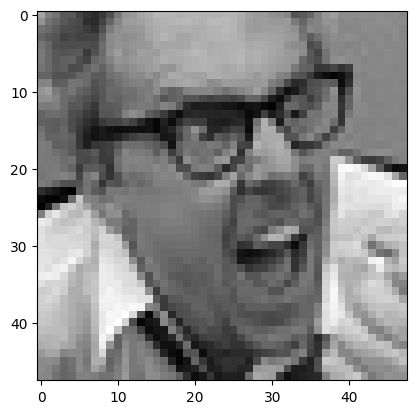

In [6]:
import matplotlib.pyplot as plt
plt.imshow(img_array)

In [7]:
Datadirectory='Face Expression DataSet/Data/Training'

In [8]:
Classes=["0","1","2","3","4","5","6"]

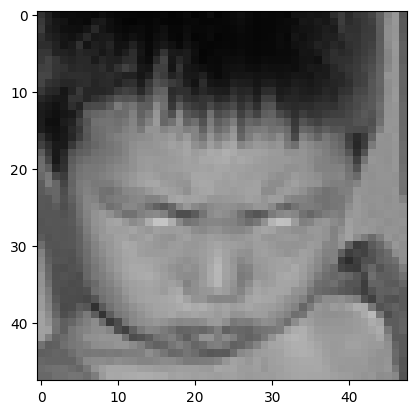

In [9]:
import cv2
for category in Classes:
    path=os.path.join(Datadirectory, category)
    for img in os.listdir(path):
        img_array=cv2.imread(os.path.join(path,img))
        plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))
        plt.show()
        break
    break

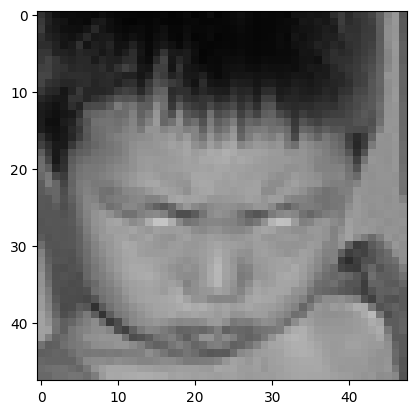

In [10]:
import os
import cv2
import matplotlib.pyplot as plt

# Define the path where images are stored
path =os.path.join(Datadirectory, category)

for img in os.listdir(path):
    img_array = cv2.imread(os.path.join(path, img))

    # Convert BGR to RGB (Corrected function name)
    img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.imshow(img_array)
    plt.show()
    
    break  # Display only the first image


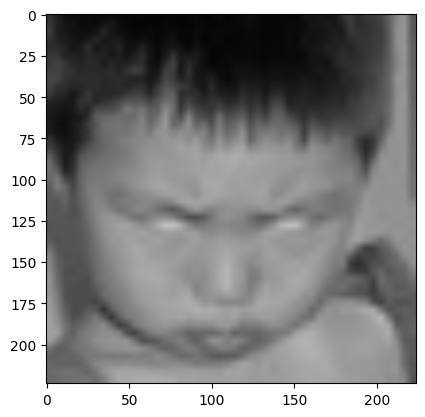

In [11]:
img_size=224
new_array=cv2.resize(img_array,(img_size,img_size))
plt.imshow(cv2.cvtColor(new_array, cv2.COLOR_BGR2RGB))
plt.show()

In [12]:
new_array.shape

(224, 224, 3)

In [13]:
#read all img and convert into array
training_Data=[]
def create_training_Data():
    for category in Classes:
        path=os.path.join(Datadirectory, category)
        class_num=Classes.index(category) #labels
        for img in os.listdir(path):
            try:
                img_array=cv2.imread(os.path.join(path,img))
                new_array=cv2.resize(img_array,(img_size,img_size))
                training_Data.append([new_array,class_num])
            except Exception as e:
                pass

In [14]:
create_training_Data()

In [15]:
print(len(training_Data))

12800


In [16]:
import random
random.shuffle(training_Data) # because it should not learn the seq.

In [17]:
X=[] # data feature
y=[] # label

for features,label in training_Data:
    X.append(features)
    y.append(label)
X=np.array(X).reshape(-1, img_size, img_size,3) #convert it to 4 deminsion 

In [18]:
X.shape

(12800, 224, 224, 3)

In [19]:
print(img_array)

[[[ 50  50  50]
  [ 32  32  32]
  [ 15  15  15]
  ...
  [133 133 133]
  [151 151 151]
  [ 86  86  86]]

 [[ 57  57  57]
  [ 34  34  34]
  [ 22  22  22]
  ...
  [138 138 138]
  [151 151 151]
  [ 89  89  89]]

 [[ 61  61  61]
  [ 30  30  30]
  [ 24  24  24]
  ...
  [142 142 142]
  [149 149 149]
  [ 89  89  89]]

 ...

 [[103 103 103]
  [100 100 100]
  [100 100 100]
  ...
  [149 149 149]
  [104 104 104]
  [ 85  85  85]]

 [[107 107 107]
  [111 111 111]
  [113 113 113]
  ...
  [151 151 151]
  [120 120 120]
  [ 86  86  86]]

 [[104 104 104]
  [104 104 104]
  [112 112 112]
  ...
  [143 143 143]
  [136 136 136]
  [ 83  83  83]]]


In [20]:
#normalize the data
X=X/255.0;

In [21]:
type(y)

list

In [22]:
Y=np.array(y)
Y.shape

(12800,)

In [23]:
#Model Tranfer Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [36]:
model=tf.keras.applications.ResNet50()

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 72s 1us/step 


In [37]:
model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [38]:
#Transfer learning tuning
base_input=model.layers[1].input


In [39]:
base_input

<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, name=keras_tensor_352>

In [40]:
base_output=model.layers[-2].output

In [41]:
base_output

<KerasTensor shape=(None, 2048), dtype=float32, sparse=False, name=keras_tensor_527>

In [42]:
final_output=layers.Dense(128)(base_output)
final_ouput=layers.Activation('relu')(final_output)
final_output=layers.Dense(64)(final_ouput)
final_ouput=layers.Activation('relu')(final_output)
final_output=layers.Dense(7,activation='softmax')(final_ouput)

In [43]:
final_output

<KerasTensor shape=(None, 7), dtype=float32, sparse=False, name=keras_tensor_533>

In [44]:
new_model=keras.Model(inputs=base_input, outputs=final_output)


In [45]:
new_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,858,695 (91.01 MB)

 Trainable params: 23,805,575 (90.81 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [46]:
new_model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [47]:
history=new_model.fit(X, Y, epochs=30, batch_size=64, verbose=1)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1599s 8s/step - accuracy: 0.3413 - loss: 1.6643
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1579s 8s/step - accuracy: 0.4989 - loss: 1.2914
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1577s 8s/step - accuracy: 0.5624 - loss: 1.1314
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1563s 8s/step - accuracy: 0.6231 - loss: 1.0030
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1569s 8s/step - accuracy: 0.6803 - loss: 0.8535
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1564s 8s/step - accuracy: 0.7189 - loss: 0.7537
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1563s 8s/step - accuracy: 0.7716 - loss: 0.6364
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1564s 8s/step - accuracy: 0.8343 - loss: 0.4503
Epoch 9/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1561s 8s/step - accuracy: 0.8764 - loss: 0.3511
Epoch 10/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1561s 8s/step - accuracy: 0.9042 - loss: 0.2756
Epoch 11/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1560s 8s/step - accuracy: 0.9356 - loss: 0.1938
Epoch 12/30
200/200 ━━━━━━━━━━

In [52]:
new_model.save("FER13ModelResNet50.h5")  # Saves as an HDF5 file


In [53]:
new_model.save("FER13ModelResNet50.keras")  # Saves as an HDF5 file


In [54]:
import tensorflow as tf
import numpy as np
import os
import cv2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the trained model
model = tf.keras.models.load_model("FER13ModelResNet50.h5")

# Define the dataset directory
Test_Directory = 'Face Expression DataSet/Data/testing'
Classes = ["0", "1", "2", "3", "4", "5", "6"]

# Image size
img_size = 224

# Function to preprocess test images
def load_test_data():
    test_data = []
    y_true = []
    
    for category in Classes:
        path = os.path.join(Test_Directory, category)
        class_num = Classes.index(category)  # Label
        
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img))
                new_array = cv2.resize(img_array, (img_size, img_size)) / 255.0  # Normalize
                test_data.append(new_array)
                y_true.append(class_num)
            except Exception as e:
                pass
    
    return np.array(test_data), np.array(y_true)

# Load test data
X_test, y_test = load_test_data()

# Check the shape
print("Test Data Shape:", X_test.shape)
print("Labels Shape:", y_test.shape)


Test Data Shape: (1003, 224, 224, 3)
Labels Shape: (1003,)


In [55]:
# Get predictions
y_pred_probs = model.predict(X_test)  # Probabilities
y_pred = np.argmax(y_pred_probs, axis=1)  # Get class with highest probability


32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 881ms/step


Accuracy: 0.4277
Precision: 0.5311
Recall: 0.4277
F1 Score: 0.4248


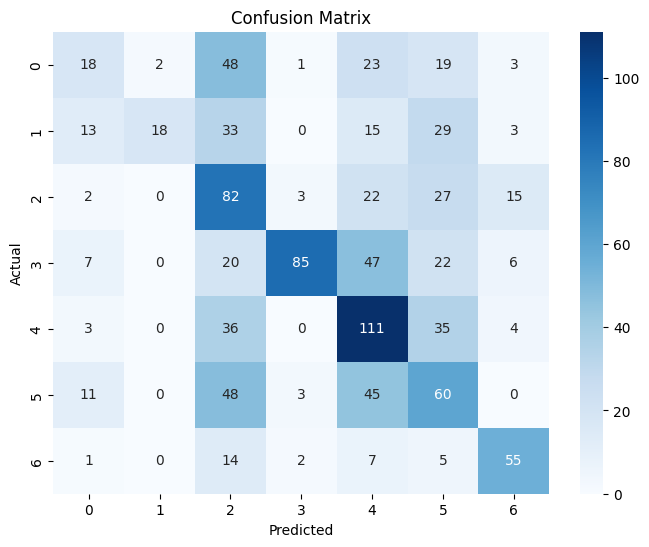

In [56]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision, Recall, F1-score
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=Classes, yticklabels=Classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [59]:
print(type(history))  # Check the type of history
print(history.keys())  # Check available keys



<class 'dict'>
dict_keys([])


In [61]:
# Load test dataset
Datadirectory = 'Face Expression DataSet/Data/Testing'
Classes = ["0", "1", "2", "3", "4", "5", "6"]

test_data = []
img_size = 224  # Ensure same size as training images

# Preprocess test images
for category in Classes:
    path = os.path.join(Datadirectory, category)
    class_num = Classes.index(category)  # Labels
    for img in os.listdir(path):
        try:
            img_array = cv2.imread(os.path.join(path, img))
            new_array = cv2.resize(img_array, (img_size, img_size))
            test_data.append([new_array, class_num])
        except Exception as e:
            pass

# Shuffle data
import random
random.shuffle(test_data)

# Separate features and labels
X_test = []
Y_test = []
for features, label in test_data:
    X_test.append(features)
    Y_test.append(label)

# Convert to NumPy arrays
X_test = np.array(X_test).reshape(-1, img_size, img_size, 3) / 255.0
Y_test = np.array(Y_test)


In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Load trained model
from tensorflow import keras
model = keras.models.load_model("FER13ModelResNet50.h5")

# Evaluate on test data
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"Test Accuracy: {accuracy:.4f}, Test Loss: {loss:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 886ms/step - accuracy: 0.4610 - loss: 3.3235
Test Accuracy: 0.4277, Test Loss: 3.4511


32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 908ms/step
              precision    recall  f1-score   support

           0       0.33      0.16      0.21       114
           1       0.90      0.16      0.27       111
           2       0.29      0.54      0.38       151
           3       0.90      0.45      0.60       187
           4       0.41      0.59      0.48       189
           5       0.30      0.36      0.33       167
           6       0.64      0.65      0.65        84

    accuracy                           0.43      1003
   macro avg       0.54      0.42      0.42      1003
weighted avg       0.53      0.43      0.42      1003



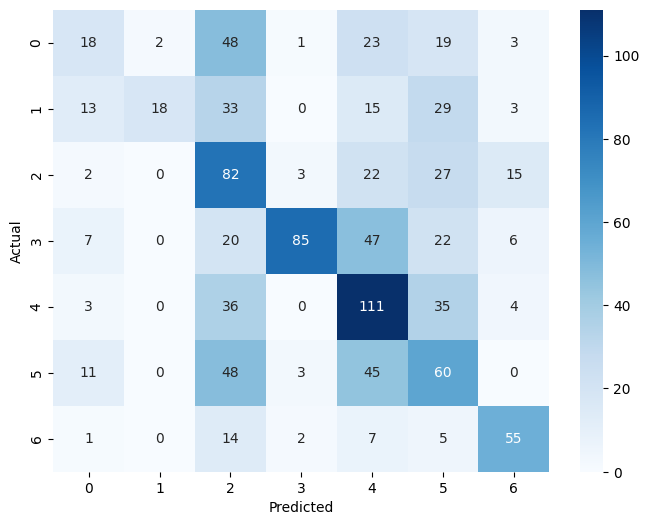

In [63]:
from sklearn.metrics import classification_report, confusion_matrix

# Make predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

# Print classification report
print(classification_report(Y_test, y_pred))

# Plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=Classes, yticklabels=Classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [64]:
import tensorflow as tf

# Load the trained model
model = tf.keras.models.load_model("FER13ModelResNet50.h5")

# Ensure training data is loaded
# X, Y = (Reload training data if lost)

# Evaluate the model
loss, accuracy = model.evaluate(X, Y)

print(f"Final Training Accuracy: {accuracy*100:.2f}%")
print(f"Final Training Loss: {loss:.4f}")


400/400 ━━━━━━━━━━━━━━━━━━━━ 349s 848ms/step - accuracy: 0.7532 - loss: 1.0532
Final Training Accuracy: 75.01%
Final Training Loss: 1.0426


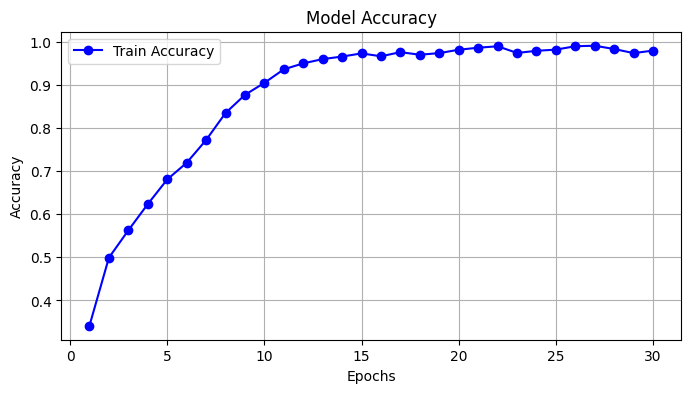

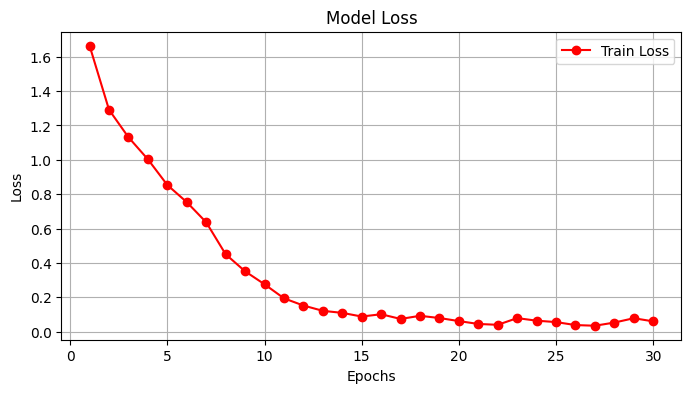

In [66]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, 31)  # 30 epochs

# Manually extracted values from logs
accuracy = [0.3413, 0.4989, 0.5624, 0.6231, 0.6803, 0.7189, 0.7716, 0.8343, 0.8764, 0.9042,
            0.9356, 0.9494, 0.9593, 0.9652, 0.9725, 0.9658, 0.9754, 0.9694, 0.9732, 0.9810,
            0.9857, 0.9890, 0.9736, 0.9785, 0.9813, 0.9891, 0.9903, 0.9826, 0.9732, 0.9790]

loss = [1.6643, 1.2914, 1.1314, 1.0030, 0.8535, 0.7537, 0.6364, 0.4503, 0.3511, 0.2756,
        0.1938, 0.1518, 0.1209, 0.1090, 0.0877, 0.1010, 0.0737, 0.0919, 0.0790, 0.0612,
        0.0445, 0.0395, 0.0785, 0.0636, 0.0554, 0.0380, 0.0342, 0.0525, 0.0779, 0.0595]

# Plot Accuracy
plt.figure(figsize=(8, 4))
plt.plot(epochs, accuracy, marker='o', label='Train Accuracy', color='blue')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid()
plt.show()

# Plot Loss
plt.figure(figsize=(8, 4))
plt.plot(epochs, loss, marker='o', label='Train Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid()
plt.show()


In [ ]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tkinter import filedialog

# Load the trained model
model = tf.keras.models.load_model("FER13ModelResNet50.h5")

# Define class labels (assuming these are the correct labels)
class_labels = ["0", "1", "2", "3", "4", "5", "6"]

# Function to process and predict an image
def predict_expression():
    # Open file dialog to select an image
    file_path = filedialog.askopenfilename(filetypes=[("Face Expression DataSet/Data/testing/1/PrivateTest_807646.jpg", "*.jpg;*.jpeg;*.png")])
    
    if not file_path:
        print("No file selected.")
        return

    # Read and preprocess the image
    img = cv2.imread(file_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    img_resized = cv2.resize(img, (224, 224))   # Resize to match model input size
    img_normalized = img_resized / 255.0        # Normalize pixel values
    
    # Reshape to match model input shape (1, 224, 224, 3)
    img_input = np.expand_dims(img_normalized, axis=0)

    # Make a prediction
    predictions = model.predict(img_input)
    predicted_class = np.argmax(predictions)  # Get the class index with highest probability
    predicted_label = class_labels[predicted_class]  # Get the class label

    # Display the image with predicted label
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_label}")
    plt.show()

# Run the function
predict_expression()


In [2]:
new_model=tf.keras.models.load_model('FER13ModelResNet50.h5')

In [3]:
frame=cv2.imread("Face Expression DataSet/Data/images.jpg")

In [4]:
frame.shape

(183, 275, 3)

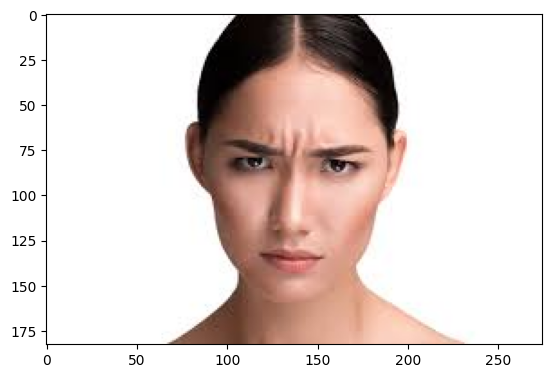

In [5]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(frame,cv2.COLOR_BGR2RGB))

In [6]:
#FACE DETECTION ALGO
faceCascade=cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [7]:
gray=cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

In [8]:
gray.shape

(183, 275)

In [9]:
faces=faceCascade.detectMultiScale(gray,1.1,4)
for x,y,w,h in faces:
    roi_gray=gray[y:y+h, x:x+w]
    roi_color=frame[y:y+h, x:x+w]
    cv2.rectangle(frame,(x,y), (x+w, y+h), (255,0,0),2)
    facess=faceCascade.detectMultiScale(roi_gray)
    if len(faces)== 0:
        print("Face not detected")
    else:
        for (ex,ey,ew,eh) in facess:
            face_roi=roi_color[ey: ey+eh, ex:ex +ew]

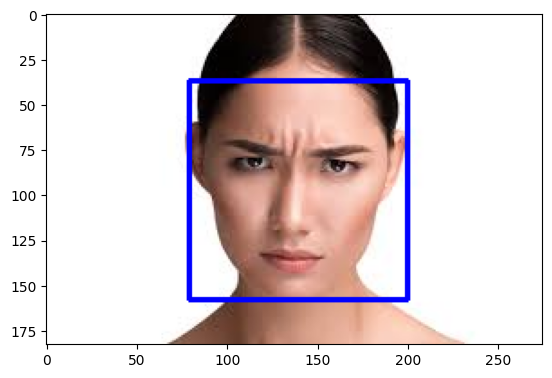

In [10]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

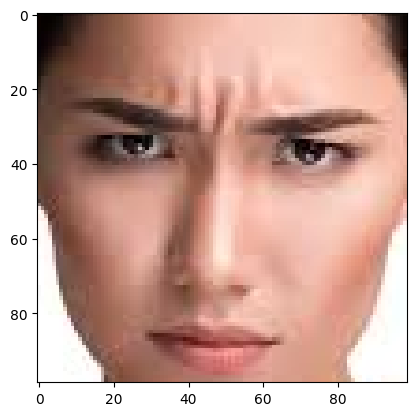

In [11]:
plt.imshow(cv2.cvtColor(face_roi, cv2.COLOR_BGR2RGB))

In [12]:
final_image=cv2.resize(face_roi,(224,224))
final_image=np.expand_dims(final_image,axis=0)
final_image=final_image/225.0

In [13]:
Predictions=new_model.predict(final_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [14]:
Predictions[0]

array([4.8837136e-03, 6.9198110e-03, 8.7351614e-01, 2.7152706e-05,
       1.5000970e-03, 1.1253493e-01, 6.1818556e-04], dtype=float32)

In [15]:
np.argmax(Predictions)

np.int64(2)

In [51]:
#REAL DEMO
import cv2
path='haarcascade_frontalface_default.xml'
font_scale=1.5
font=cv2.FONT_HERSHEY_PLAIN

rectangle_bgr=(225,225,225)
img=np.zeros((500,500))
text="Some text in a box!"
(text_width,text_height)=cv2.getTextSize(text,font,fontScale=font_scale,thickness=1)[0]
text_offset_x=10
text_offset_y=img.shape[0]-25

box_coords=((text_offset_x, text_offset_y), (text_offset_x + text_width + 2, text_offset_y-text_height-2))
cv2.rectangle(img, box_coords[0], box_coords[1], rectangle_bgr, cv2.FILLED)
cv2.putText(img,text,(text_offset_x, text_offset_y), font, fontScale=font_scale, color=(0,0,0), thickness=1)

cap=cv2.VideoCapture(1)
if not cap.isOpened():
    cap= cv2.VideoCapture(0)
if not cap.isOpened():
    raise IOError("Cannot open Webcam")

while True:
    ret, frame=cap.read()
    faceCascade=cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    gray=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    faces=faceCascade.detectMultiScale(gray,1.1,4)
    for x,y,w,h in faces:
        roi_gray=gray[y:y+h, x:x+w]
        roi_color=frame[y:y+h, x:x+w]
        cv2.rectangle(frame,(x,y), (x+w, y+h), (255,0,0),2)
        facess=faceCascade.detectMultiScale(roi_gray)
        if len(faces)== 0:
            print("Face not detected")
        else:
            for (ex,ey,ew,eh) in facess:
                face_roi=roi_color[ey: ey+eh, ex:ex +ew]
    final_image=cv2.resize(face_roi,(224,224))
    final_image=np.expand_dims(final_image,axis=0)
    final_image=final_image/225.0

    font=cv2.FONT_HERSHEY_SIMPLEX
    Predictions=new_model.predict(final_image)

    font_scale=1.5
    font=cv2.FONT_HERSHEY_PLAIN

    if(np.argmax(Predictions)==0):
        status="Angry"
        x1,y1,w1,h1=0,0,175,75
        cv2.rectangle(frame,(x1,x1),(x1+w1,y1+h1),(0,0,0),-1)

        cv2.putText(frame,status,(x1+ int(w1/10),y1 +int(h1/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0,255),2)
        cv2.putText(frame,status,(100,150), font, 3,(0,0,255),2,cv2.LINE_4)
        cv2.rectangle(frame,(x,y), (x+w, y+h),(0,0,255))

        
    elif (np.argmax(Predictions)==1):
        status="Disgust"
        x1,y1,w1,h1=0,0,175,75
        cv2.rectangle(frame,(x1,x1),(x1+w1,y1+h1),(0,0,0),-1)

        cv2.putText(frame,status,(x1+ int(w1/10),y1 +int(h1/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0,255),2)
        cv2.putText(frame,status,(100,150), font, 3,(0,0,255),2,cv2.LINE_4)
        cv2.rectangle(frame,(x,y), (x+w, y+h),(0,0,255))

    elif (np.argmax(Predictions)==3):
        status="Happy"
        x1,y1,w1,h1=0,0,175,75
        cv2.rectangle(frame,(x1,x1),(x1+w1,y1+h1),(0,0,0),-1)

        cv2.putText(frame,status,(x1+ int(w1/10),y1 +int(h1/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0,255),2)
        cv2.putText(frame,status,(100,150), font, 3,(0,0,255),2,cv2.LINE_4)
        cv2.rectangle(frame,(x,y), (x+w, y+h),(255,0,0))

    elif (np.argmax(Predictions)==4):
        status="Sad"
        x1,y1,w1,h1=0,0,175,75
        cv2.rectangle(frame,(x1,x1),(x1+w1,y1+h1),(0,0,0),-1)

        cv2.putText(frame,status,(x1+ int(w1/10),y1 +int(h1/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0,255),2)
        cv2.putText(frame,status,(100,150), font, 3,(0,0,255),2,cv2.LINE_4)
        cv2.rectangle(frame,(x,y), (x+w, y+h),(255,0,0))


    elif (np.argmax(Predictions)==5):
        status="Suprise"
        x1,y1,w1,h1=0,0,175,75
        cv2.rectangle(frame,(x1,x1),(x1+w1,y1+h1),(0,0,0),-1)

        cv2.putText(frame,status,(x1+ int(w1/10),y1 +int(h1/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0,255),2)
        cv2.putText(frame,status,(100,150), font, 3,(0,0,255),2,cv2.LINE_4)
        cv2.rectangle(frame,(x,y), (x+w, y+h),(255,0,0))

    else:
        status="Neural"
        x1,y1,w1,h1=0,0,175,75
        cv2.rectangle(frame,(x1,x1),(x1+w1,y1+h1),(0,0,0),-1)

        cv2.putText(frame,status,(x1+ int(w1/10),y1 +int(h1/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0,255),2)
        cv2.putText(frame,status,(100,150), font, 3,(0,0,255),2,cv2.LINE_4)
        cv2.rectangle(frame,(x,y), (x+w, y+h),(255,0,0))


    cv2.imshow("Face Emotion Recogition",frame)
    
    if cv2.waitKey(2) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyALLWindows()
        
        
        

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

KeyboardInterrupt: 

In [54]:
#RUNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN
import cv2
import numpy as np
from collections import Counter
from tensorflow.keras.models import load_model

# Load the trained model
new_model = load_model("FER13Model.keras")  # Replace with your actual model path

# Load face detection model
faceCascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Initialize webcam
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise IOError("Cannot open Webcam")

# Store last few predictions for stability
prediction_history = []
history_size = 5  # Number of recent predictions to consider

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = faceCascade.detectMultiScale(gray, 1.1, 4)

    for (x, y, w, h) in faces:
        roi_color = frame[y:y+h, x:x+w]
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

        # Resize face ROI to match model input
        final_image = cv2.resize(roi_color, (224, 224))
        final_image = np.expand_dims(final_image, axis=0) / 255.0  # Normalize

        # Make prediction
        Predictions = new_model.predict(final_image)
        prediction_history.append(np.argmax(Predictions))

        # Keep only the last `history_size` predictions
        if len(prediction_history) > history_size:
            prediction_history.pop(0)

        # Choose the most common prediction
        most_common_prediction = Counter(prediction_history).most_common(1)[0][0]
        emotion_dict = {0: "Angry", 1: "Disgust", 2: "Fear", 3: "Happy", 4: "Sad", 5: "Surprise", 6: "Neutral"}
        status = emotion_dict.get(most_common_prediction, "Unknown")

        # Display emotion label
        cv2.rectangle(frame, (0, 0), (175, 50), (0, 0, 0), -1)
        cv2.putText(frame, status, (10, 35), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Show video
    cv2.imshow("Face Emotion Recognition", frame)

    # Exit on 'q' key
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━

KeyboardInterrupt: 